In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [223]:
from xgboost import XGBRFClassifier


In [224]:
##Data Loading And Understanding

data = pd.read_csv(r'/content/churn_customer_data.csv')


In [225]:
print(data.head())

# Get basic information about the dataset
print(data.info())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [226]:
data=data.drop(columns=["customerID"])

In [227]:
data.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [228]:
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [229]:
#printing the unique values in all the columns
for col in data.columns:
    print(col,data[col].unique())
    print("-"*50)

gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
-------

In [230]:
data.isnull()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [231]:
#data["TotalCharges"]=data["TotalCharges"].astype(float)

In [232]:
data[data["TotalCharges"]==" "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [233]:
len(data[data["TotalCharges"]==" "])

11

In [234]:
# Convert 'TotalCharges' to a numeric type, coercing errors to NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Fill any resulting NaN values with the median
median_total_charges = data['TotalCharges'].median()
data['TotalCharges'].fillna(median_total_charges, inplace=True)

# --- Target Variable Creation ---
# Create the numerical target variable FIRST to avoid data leakage
data['churn_numeric'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Now, drop the original categorical 'Churn' column
data = data.drop(columns=['Churn'])
print("Data cleaning and target variable creation complete.")

Data cleaning and target variable creation complete.


/tmp/ipython-input-1612532342.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(median_total_charges, inplace=True)


In [235]:
##understnad the distribution of target column
print(data["churn_numeric"].value_counts())

churn_numeric
0    5174
1    1869
Name: count, dtype: int64


In [236]:
#insights
#1. customer id removal
#2.no missing values in the dataset
#3. missing values in the totatalcharges column were replaced with o
#4. class imbalance identified in the traget.


In [237]:
#5. Exploratory Data Analysis (EDA)
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'churn_numeric'],
      dtype='object')

In [238]:
data.shape

(7043, 20)

In [239]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,churn_numeric
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928,0.265370
std,0.368612,24.559481,30.090047,2265.270398,0.441561
min,0.000000,0.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.500000,402.225000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [240]:
#Numerical Feature Ananlysis :-
#understand the distribution of numerical features:-


def plot_histogram(data, column_name):
    plt.figure(figsize=(8, 5))

    # Plot histogram with KDE
    sns.histplot(data[column_name], kde=True, bins=30)

    plt.title(f"Distribution of {column_name}")

    # Calculate mean and median
    col_mean = data[column_name].mean()
    col_median = data[column_name].median()

    # Add vertical lines for mean and median
    plt.axvline(col_mean, color="red", linestyle="--", label=f"Mean: {col_mean:.2f}")
    plt.axvline(col_median, color="blue", linestyle=":", label=f"Median: {col_median:.2f}")

    plt.legend()
    plt.show()



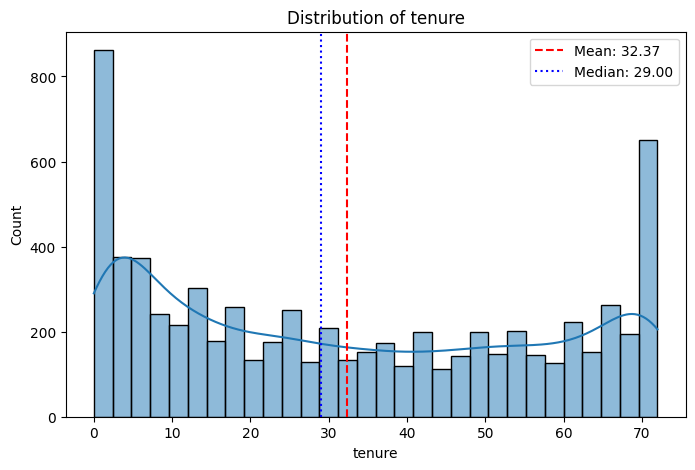

In [241]:
plot_histogram(data,"tenure")

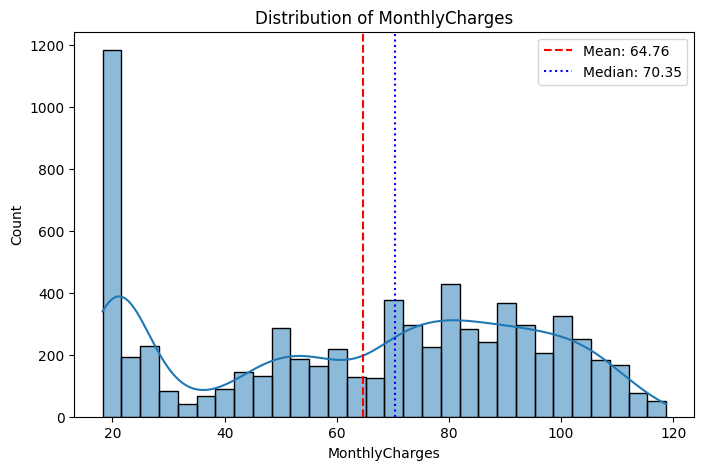

In [242]:
plot_histogram(data,"MonthlyCharges")

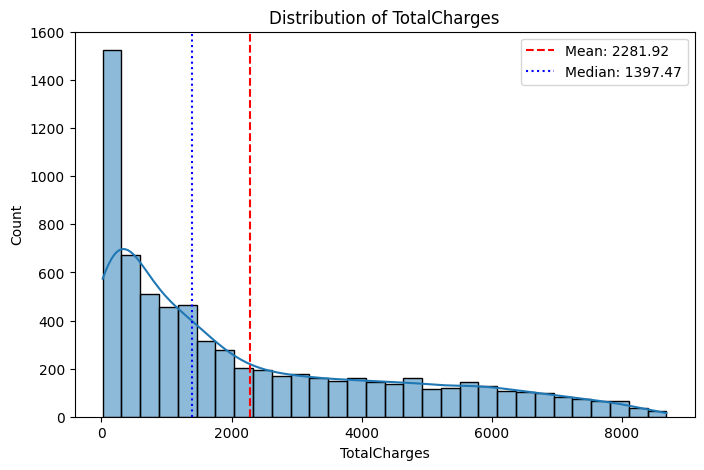

In [243]:
plot_histogram(data,"TotalCharges")

In [244]:
#Box plot for numerical features

def plot_boxplot(data,column_name):
    plt.figure(figsize=(5, 3))

    # Plot histogram with KDE
    sns.boxplot(y=data[column_name])

    plt.title(f"Box Plot of {column_name}")
    plt.ylabel(column_name)

    plt.show


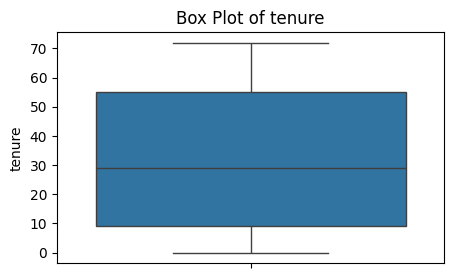

In [245]:
plot_boxplot(data,"tenure")

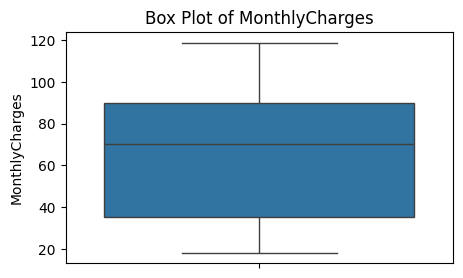

In [246]:
plot_boxplot(data,"MonthlyCharges")

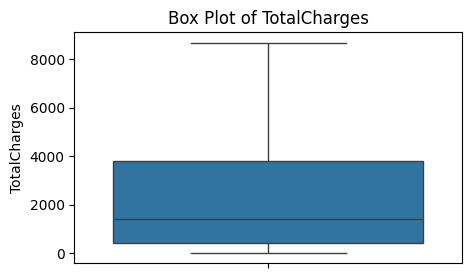

In [247]:
plot_boxplot(data,"TotalCharges")

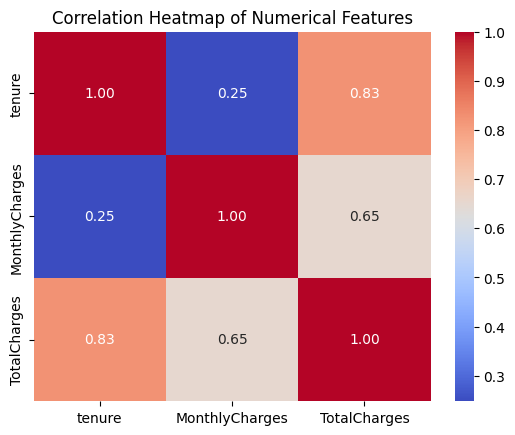

In [248]:
#correlation Heatmap for Numerical Columns
sns.heatmap(
    data[["tenure", "MonthlyCharges", "TotalCharges"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

In [249]:
#Categorical Features Analysis
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'churn_numeric'],
      dtype='object')

In [250]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


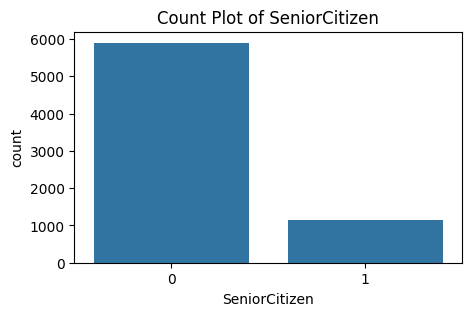

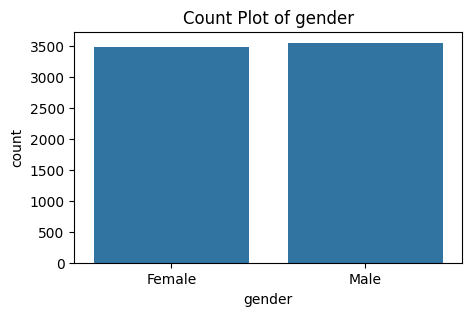

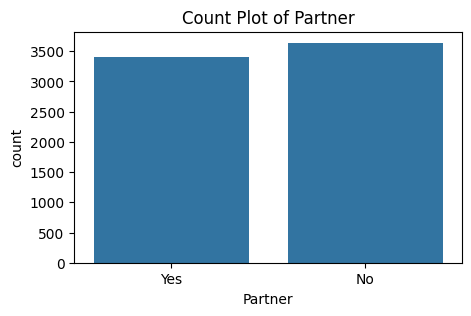

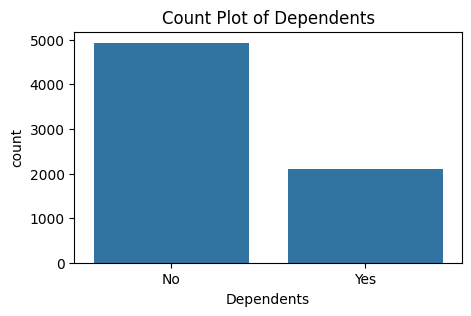

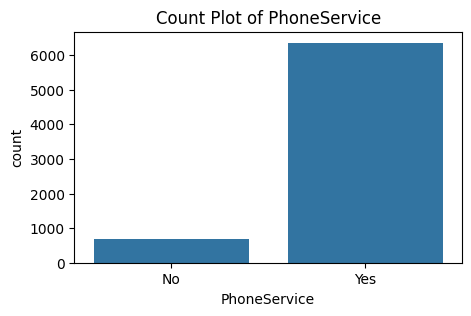

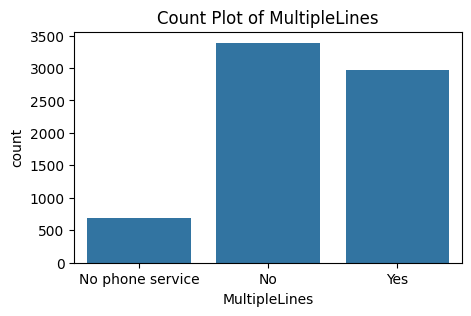

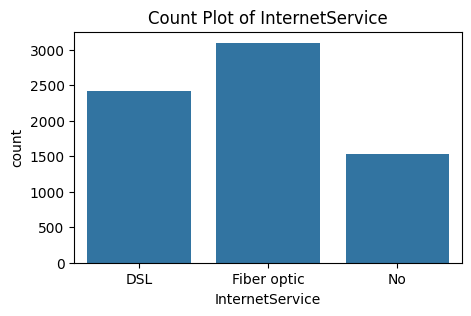

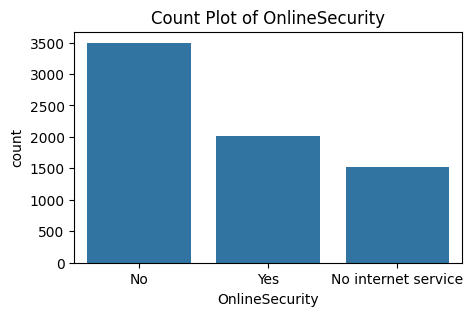

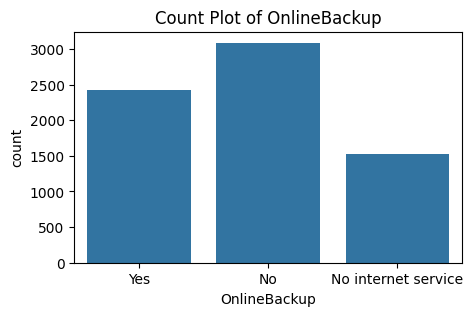

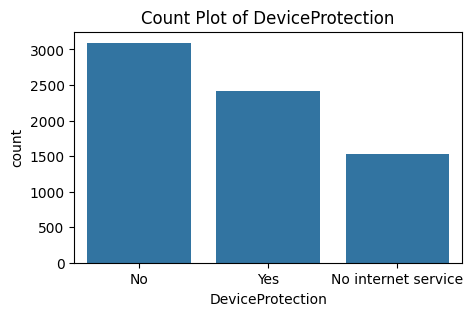

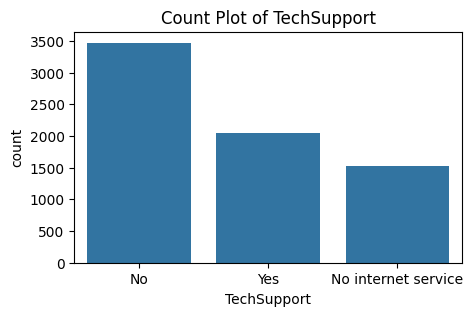

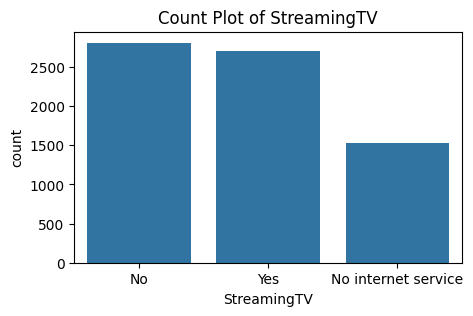

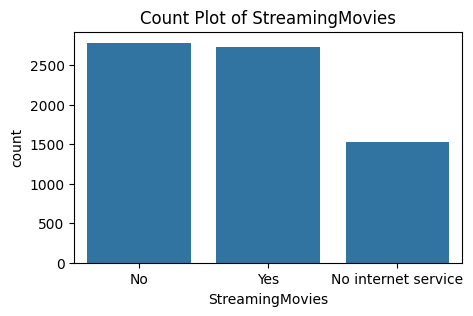

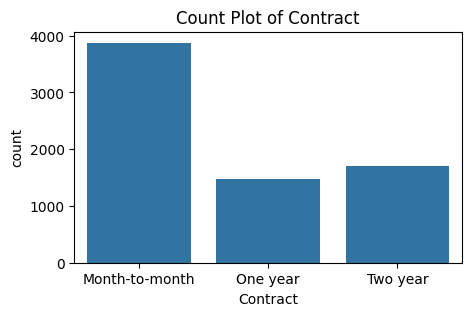

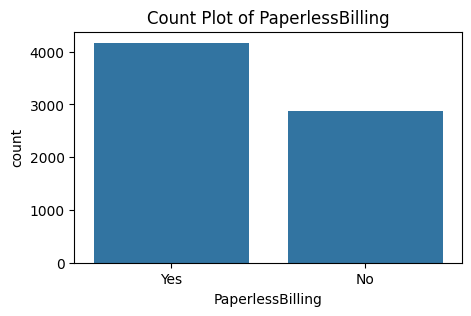

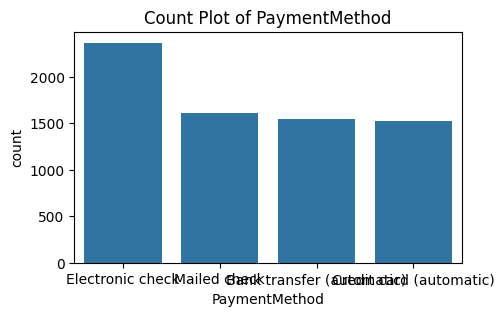

In [251]:
#countPlot for Categorical Column
object_cols=data.select_dtypes(include="object").columns.to_list()

object_cols=["SeniorCitizen"]+object_cols
for col in object_cols:
    plt.figure(figsize=(5, 3))
    sns.countplot(x=data[col])

    plt.title(f"Count Plot of {col}")
    plt.show()

In [252]:
# Data Preprocessing
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn_numeric
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [253]:
# This cell is no longer needed as the mapping is done in the main execution block.
# It can be removed or left as is (commented out).
# data["churn_numeric"] = data["churn_numeric"].map({"Yes": 1, "No": 0})
#
# # Optionally check for NaNs after mapping
# if data["churn_numeric"].isnull().sum() > 0:
#     print("Warning: Some values in 'churn_numeric' are not 'Yes' or 'No'.")

In [254]:
data.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn_numeric
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [255]:
print(data["churn_numeric"].value_counts())

churn_numeric
0    5174
1    1869
Name: count, dtype: int64


In [256]:
import pickle
# --- Label Encoding ---
# Identify categorical columns that need encoding
categorical_cols = data.select_dtypes(include="object").columns

encoders = {}
for column in categorical_cols:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    encoders[column] = le

# Save the encoders to a pickle file for the predictive system
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)
print("Categorical features encoded and encoders saved to 'encoders.pkl'.")

Categorical features encoded and encoders saved to 'encoders.pkl'.


In [257]:
# ===============================
# Churn Prediction Script (Numeric-Compatible)
# ===============================

import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRFClassifier
from imblearn.over_sampling import SMOTE

# -------------------------------
# 1. Train and Evaluate Models
# -------------------------------
def train_and_evaluate_models(data):
    """Splits data, handles imbalance, trains multiple models, encodes categorical features, and saves the best model."""

    # Data checks
    if data.empty:
        raise ValueError("The dataset is empty. Load your data correctly before training.")
    if 'churn_numeric' not in data.columns:
        raise ValueError("Target column 'churn_numeric' not found. Create it first.")

    # Drop rows with missing target
    data = data.dropna(subset=['churn_numeric'])
    if data.empty:
        raise ValueError("No data left after dropping missing target values.")

    # Separate features and target
    X = data.drop(columns=['churn_numeric'])
    y = data['churn_numeric']

    # Detect categorical columns automatically
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"Categorical columns detected: {categorical_cols}")

    # One-hot encode categorical features
    X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    feature_names = X_encoded.columns.tolist()

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_encoded, y, test_size=0.2, random_state=42, stratify=y
    )

    # Handle class imbalance
    smote = SMOTE(random_state=42)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
    print("Class imbalance handled using SMOTE.")

    # Define models
    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost RF": XGBRFClassifier(random_state=42)
    }

    best_model = None
    best_accuracy = 0.0

    # Train and evaluate
    for name, model in models.items():
        print("\n" + "="*20)
        print(f"Training and Evaluating: {name}")
        print("="*20)

        model.fit(X_train_smote, y_train_smote)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        print(f"Accuracy Score: {accuracy:.4f}")
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        print("Classification Report:")
        print(classification_report(y_test, y_pred))

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_model = model

    # Save the best model along with feature info
    if best_model:
        model_data = {
            "model": best_model,
            "feature_names": feature_names
        }
        with open("best_churn_model.pkl", "wb") as f:
            pickle.dump(model_data, f)
        print("\n" + "="*20)
        print(f"Best performing model ({best_model.__class__.__name__}) saved to 'best_churn_model.pkl'.")
        print("="*20)

# -------------------------------
# 2. Predict for a New Customer
# -------------------------------
def run_predictive_system(new_customer, training_data=None):
    """
    Predict churn for a new customer using the saved best model.
    Automatically handles missing features using defaults from training data.

    Parameters:
    - new_customer: dict of customer features
    - training_data: optional, pandas DataFrame used to compute default values
    """

    # Load saved model
    with open("best_churn_model.pkl", "rb") as f:
        model_data = pickle.load(f)
    model = model_data["model"]
    feature_names = model_data["feature_names"]

    # Convert input to DataFrame
    input_df = pd.DataFrame([new_customer])

    # Fill missing numeric columns with 0 (or mean from training_data if provided)
    for col in feature_names:
        if col not in input_df.columns:
            # Check if this is a numeric feature
            if training_data is not None and col in training_data.columns:
                if pd.api.types.is_numeric_dtype(training_data[col]):
                    input_df[col] = training_data[col].mean()
                else:
                    input_df[col] = "Missing"
            else:
                input_df[col] = 0

    # Automatically convert string features to numeric (for numeric-trained model)
    numeric_input = pd.DataFrame(columns=feature_names)
    for col in feature_names:
        base_col = col.split("_")[0]
        val = col.split("_")[1] if "_" in col else None
        if base_col in input_df.columns:
            if val is not None and str(input_df.loc[0, base_col]) == val:
                numeric_input.loc[0, col] = 1
            else:
                numeric_input.loc[0, col] = 0
        else:
            numeric_input.loc[0, col] = input_df.loc[0, col]

    # Fill any remaining NaNs with 0
    numeric_input = numeric_input.fillna(0)

    # Predict
    prediction = model.predict(numeric_input)[0]
    prediction_proba = None
    if hasattr(model, "predict_proba"):
        prediction_proba = model.predict_proba(numeric_input)[0][1]  # probability of churn
        print(f"Predicted churn probability: {prediction_proba:.2f}")

    print(f"Predicted churn for the new customer: {prediction}")

# -------------------------------
# 3. Main Execution
# -------------------------------
if __name__ == "__main__":
    try:
        # Ensure your dataset is loaded, e.g.:
        # data = pd.read_csv("your_churn_dataset.csv")
        if 'data' not in globals():
            raise ValueError("Dataset 'data' is not loaded. Load it first.")

        data_for_training = data.copy()

        # Train models and save the best
        train_and_evaluate_models(data_for_training)

        # Example new customer prediction (raw strings allowed)
        new_customer_example = {
            'gender': 'Female',
            'SeniorCitizen': 0,
            'Partner': 'No',
            'Dependents': 'No',
            'tenure': 1,
            'PhoneService': 'Yes',
            'MultipleLines': 'No',
            'InternetService': 'Fiber optic',
            'OnlineSecurity': 'No',
            'OnlineBackup': 'No',
            'DeviceProtection': 'No',
            'TechSupport': 'No',
            'StreamingTV': 'No',
            'StreamingMovies': 'No',
            'Contract': 'Month-to-month',
            'PaperlessBilling': 'Yes',
            'PaymentMethod': 'Electronic check',
            'MonthlyCharges': 70.70,
            'TotalCharges': 151.65
        }

        run_predictive_system(new_customer_example)

    except Exception as e:
        print("Error:", e)


Categorical columns detected: []
Class imbalance handled using SMOTE.

Training and Evaluating: Decision Tree
Accuracy Score: 0.7204
Confusion Matrix:
[[816 219]
 [175 199]]
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      1035
           1       0.48      0.53      0.50       374

    accuracy                           0.72      1409
   macro avg       0.65      0.66      0.65      1409
weighted avg       0.73      0.72      0.73      1409


Training and Evaluating: Random Forest
Accuracy Score: 0.7779
Confusion Matrix:
[[875 160]
 [153 221]]
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1035
           1       0.58      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409


Training and Evaluati

/tmp/ipython-input-3433725765.py:143: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numeric_input = numeric_input.fillna(0)


In [258]:
# Example new customer with only 5 features
new_customer_short = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'tenure': 3,
    'MonthlyCharges': 75.5,
    'InternetService': 'Fiber optic'
}

# Run the predictive system
# Pass your training data if you want numeric defaults to use column means
run_predictive_system(new_customer_short, training_data=data_for_training)


Predicted churn probability: 0.69
Predicted churn for the new customer: 1


/tmp/ipython-input-3433725765.py:143: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numeric_input = numeric_input.fillna(0)
